# Rising Variance; methodology replication

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Parameters used for the phosphorus model, based on the paper.

b = 0.001      # permanent burial rate of sediment P (y^-1)
h = 0.15       # hydrologic loss / outflow rate (y^-1)
m = 2.4        # water P at which recycling is half-maximal (g m^-2)
r = 0.019      # maximum recycling rate (g m^-2 y^-1)
q = 8          # steepness of recycling function
s = 0.7        # sedimentation rate (y^-1)

sigma = 0.01    # SD of recycling noise

# Numerical settings from the paper
n_traj = 1000
n_steps = 10800 #NOTE: paper says 36 timesteps per year, for 300 years which would equal 10800, not 1080 which they say they use.
dt = 1 / 36

seed = 42

## Calculations

In [3]:
# Creating water P values

X = np.linspace(0.001, 12, 40000)

# Equation 4 from the paper: recycling function
R = X**q / (m**q + X**q)

# From dM/dt = 0:
# M* = sX / (b + rR(X))
M_star = (s * X) / (b + r * R)

# At equilibrium dX/dt = 0 and H = 1:
# cU = (s+h)X - rMR
P_input = (s + h) * X - r * M_star * R

In [4]:
# Find the folds of the equilibrium curve

dP = np.gradient(P_input, X)

# Stable where dL/dX > 0
stable = dP > 0

dP = np.gradient(P_input, X)

# Find changes in sign of the slope
i_fold = np.where(
    np.sign(dP[:-1]) != np.sign(dP[1:])
)[0]

P_lower = P_input[i_fold[1]]
P_upper = P_input[i_fold[0]]

X_lower = X[i_fold[1]]
X_upper = X[i_fold[0]]


print("Lower fold of X =", X_lower)

print("Upper fold of X =", X_upper)

Lower fold of X = 2.4416576164404113
Upper fold of X = 1.3494213355333884


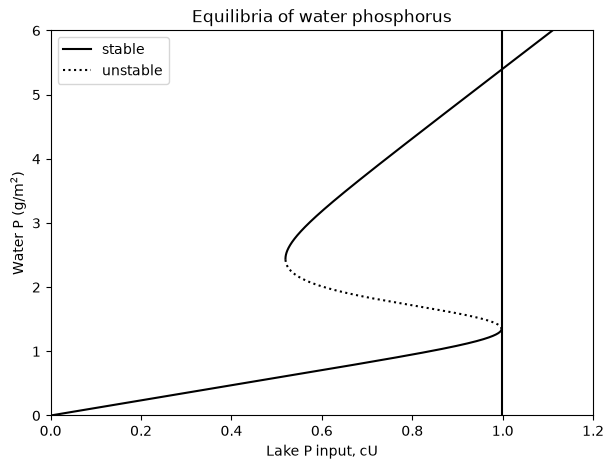

In [5]:
# Equilibrium curve
# We cannot reproduce the equilibrium calculation originally because there isn't enough information,
# but the natural x-axis from the equations is cU.

plt.figure(figsize=(7, 5))

plt.plot(
    np.where(stable, P_input, np.nan),
    np.where(stable, X, np.nan),
    "k-",
    label="stable"
)

plt.plot(
    P_input[~stable],
    X[~stable],
    "k:",
    label="unstable"
)

# Upper fold found automatically
plt.axvline(
    P_upper,
    color="k"
)

plt.xlim(0, 1.2)
plt.ylim(0, 6)

plt.xlabel("Lake P input, cU")
plt.ylabel("Water P (g/m$^2$)")
plt.title("Equilibria of water phosphorus")

plt.legend()
plt.show()

In [6]:
# Monte Carlo stationary distributions


P_values = np.linspace(P_input.min(), 1.2, 50)


means = []
sds = []

rng = np.random.default_rng(seed)

n_traj = 1000
n_steps = 10800
dt = 1 / 36

for P in P_values:

    # Find equilibrium crossings
    crossings = np.where(
        np.diff(np.sign(P_input - P)) != 0
    )[0]

    if len(crossings) == 0:
        means.append(np.nan)
        sds.append(np.nan)
        continue

    # Lowest equilibrium = oligotrophic equilibrium
    i = crossings[0]

    x_eq = X[i]
    M0 = M_star[i]

    # 1000 different initial values of X
    x = rng.uniform(0, 10, n_traj)

    # M starts at the oligotrophic steady state
    M = np.full(n_traj, M0)

    # Euler-Maruyama
    for step in range(n_steps):

        R_x = x**q / (m**q + x**q)

        noise = (
            sigma
            * M
            * R_x
            * np.sqrt(dt)
            * rng.standard_normal(n_traj)
        )

        x_new = (
            x
            + (
                P
                - (s + h) * x
                + r * M * R_x
            ) * dt
            + noise
        )

        M_new = (
            M
            + (
                s * x
                - b * M
                - r * M * R_x
            ) * dt
            - noise
        )

        x = np.maximum(x_new, 1e-12)
        M = np.maximum(M_new, 1e-12)

    # Final 1000 values
    means.append(x.mean())
    sds.append(x.std())

## Creating the plots

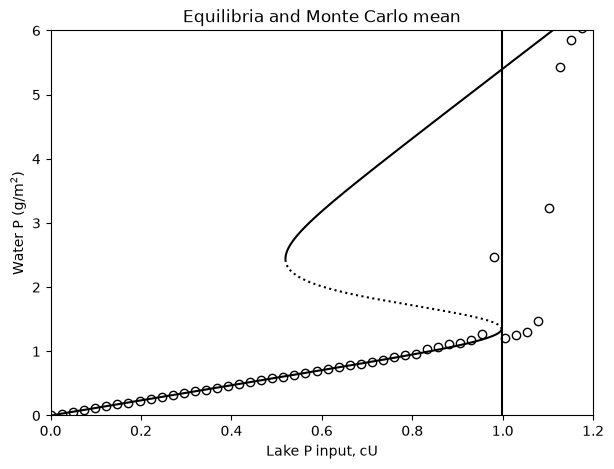

In [14]:
# Figure 2a
plt.figure(figsize=(7, 5))

plt.plot(
    np.where(stable, P_input, np.nan),
    np.where(stable, X, np.nan),
    "k-"
)

plt.plot(
    P_input[~stable],
    X[~stable],
    "k:"
)

plt.plot(
    P_values,
    means,
    "ko",
    markerfacecolor="none"
)

plt.axvline(
    P_upper,
    color="k"
)

plt.xlim(0, 1.2)
plt.ylim(0, 6)

plt.xlabel("Lake P input, cU")
plt.ylabel("Water P (g/m$^2$)")
plt.title("Equilibria and Monte Carlo mean")

plt.show()

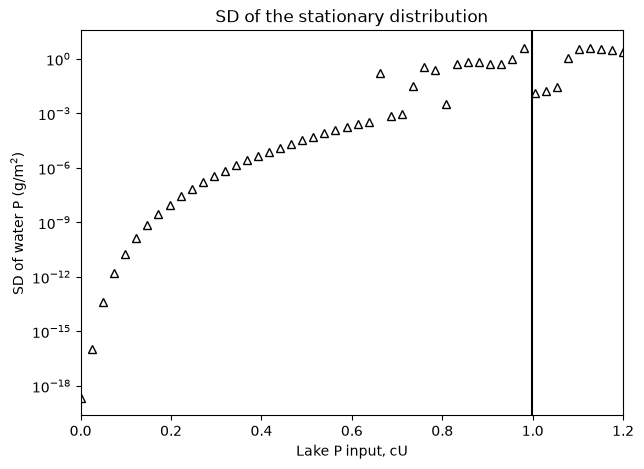

In [11]:
#Figure 2b
plt.figure(figsize=(7, 5))

plt.semilogy(
    P_values,
    sds,
    "k^",
    markerfacecolor="none"
)

plt.axvline(
    P_upper,
    color="k"
)

plt.xlim(0, 1.2)

plt.xlabel("Lake P input, cU")
plt.ylabel("SD of water P (g/m$^2$)")
plt.title("SD of the stationary distribution")

plt.show()